# Import

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, chisquare, lognorm, gamma, skewnorm

df = pd.read_csv("Results_Sample_2.csv")

# Distribution

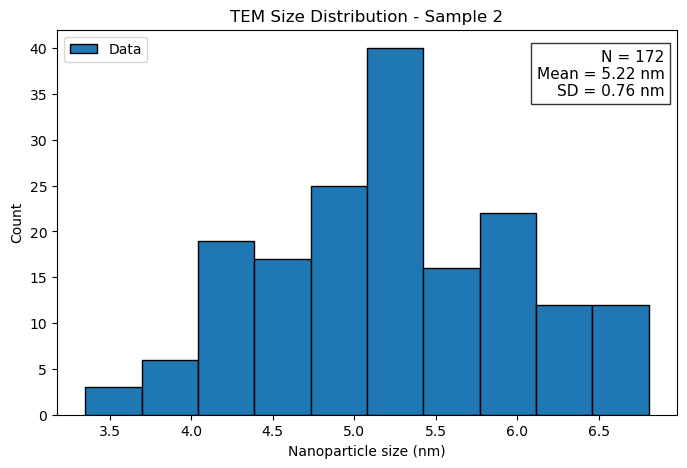

Mean size = 5.22 nm
Standard deviation = 0.76 nm


In [111]:
# Extraire les tailles (en nm)
sizes = df["Length"]

# Calculs statistiques
mean_size = np.mean(sizes)
std_size = np.std(sizes, ddof=1)  # écart-type expérimental
n_measurements = len(sizes)

# Création de l'histogramme
plt.figure(figsize=(8,5))

plt.hist(sizes, bins=10, edgecolor="black", label="Data")

# Affichage moyenne ± écart-type dans le graphique
plt.text(0.98, 0.95, f"N = {n_measurements}\nMean = {mean_size:.2f} nm\nSD = {std_size:.2f} nm", transform=plt.gca().transAxes, fontsize=11, verticalalignment="top",
    horizontalalignment="right", bbox=dict(facecolor="white", alpha=0.8))

# Labels
plt.xlabel("Nanoparticle size (nm)")
plt.ylabel("Count")
plt.title("TEM Size Distribution - Sample 2")
plt.legend()
plt.grid(False)

plt.show()

# Affichage console
print(f"Mean size = {mean_size:.2f} nm")
print(f"Standard deviation = {std_size:.2f} nm")

# Gaussian fit

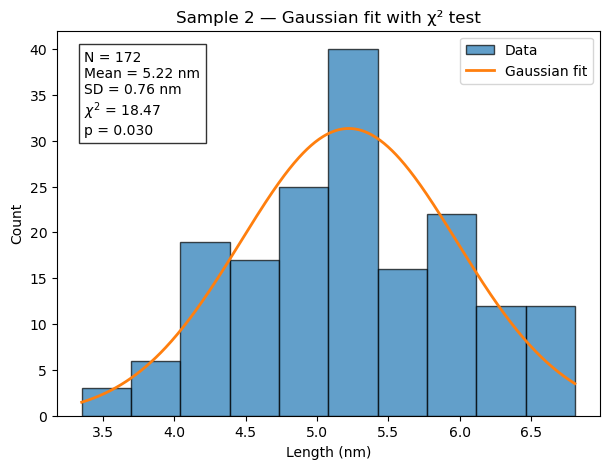

In [112]:
sizes = df["Length"].dropna()
N = len(sizes)

bins = 10
observed, bin_edges = np.histogram(sizes, bins=bins)
bin_width = bin_edges[1] - bin_edges[0]

mu, sigma = norm.fit(sizes)

cdf_values = norm.cdf(bin_edges, mu, sigma)
expected = N * np.diff(cdf_values)

expected = expected * observed.sum() / expected.sum()

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

x = np.linspace(sizes.min(), sizes.max(), 500)
pdf = norm.pdf(x, mu, sigma)


plt.figure(figsize=(7, 5))
plt.hist(sizes, bins=10, alpha=0.7, edgecolor="black", label="Data")
plt.plot(x, pdf * N * bin_width, linewidth=2, label="Gaussian fit")

plt.xlabel("Length (nm)")
plt.ylabel("Count")
plt.title("Sample 2 — Gaussian fit with χ² test")

plt.text(
    0.05, 0.95,
    f"N = {N}\n"
    f"Mean = {mu:.2f} nm\n"
    f"SD = {sigma:.2f} nm\n"
    f"$\\chi^2$ = {chi2:.2f}\n"
    f"p = {p_value:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid(False)
plt.show()

# Log-normal fit

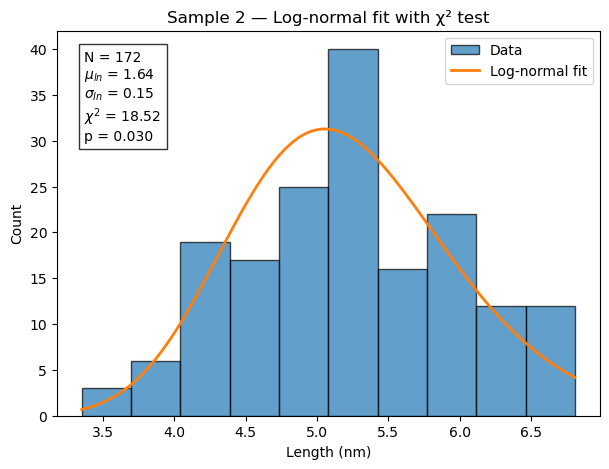

In [113]:
sizes = df["Length"].dropna()
N = len(sizes)

bins = 10
observed, bin_edges = np.histogram(sizes, bins=bins)
bin_width = bin_edges[1] - bin_edges[0]

shape, loc, scale = lognorm.fit(sizes, floc=0)
mu_ln = np.log(scale)
sigma_ln = shape

cdf_values = lognorm.cdf(bin_edges, shape, loc, scale)
expected = N * np.diff(cdf_values)

expected = expected * observed.sum() / expected.sum()

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

x = np.linspace(sizes.min(), sizes.max(), 500)
pdf = lognorm.pdf(x, shape, loc, scale)

plt.figure(figsize=(7, 5))
plt.hist(sizes, bins=10, alpha=0.7, edgecolor="black", label="Data")
plt.plot(x, pdf * N * bin_width, linewidth=2, label="Log-normal fit")

plt.xlabel("Length (nm)")
plt.ylabel("Count")
plt.title("Sample 2 — Log-normal fit with χ² test")

plt.text(
    0.05, 0.95,
    f"N = {N}\n"
    f"$\\mu_{{ln}}$ = {mu_ln:.2f}\n"
    f"$\\sigma_{{ln}}$ = {sigma_ln:.2f}\n"
    f"$\\chi^2$ = {chi2:.2f}\n"
    f"p = {p_value:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid(False)
plt.show()

# Gamma fit

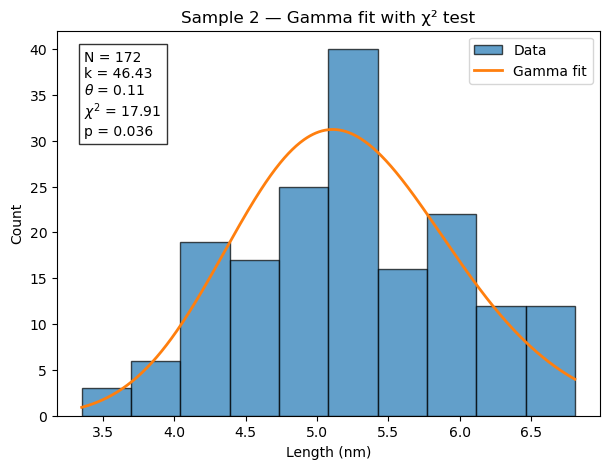

In [114]:
sizes = df["Length"].dropna()
N = len(sizes)

bins = 10
observed, bin_edges = np.histogram(sizes, bins=bins)
bin_width = bin_edges[1] - bin_edges[0]

k, loc, theta = gamma.fit(sizes, floc=0)

cdf_values = gamma.cdf(bin_edges, k, loc, theta)
expected = N * np.diff(cdf_values)

expected = expected * observed.sum() / expected.sum()

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

x = np.linspace(sizes.min(), sizes.max(), 500)
pdf = gamma.pdf(x, k, loc, theta)

plt.figure(figsize=(7, 5))
plt.hist(sizes, bins=10, alpha=0.7, edgecolor="black", label="Data")
plt.plot(x, pdf * N * bin_width, linewidth=2, label="Gamma fit")

plt.xlabel("Length (nm)")
plt.ylabel("Count")
plt.title("Sample 2 — Gamma fit with χ² test")

plt.text(
    0.05, 0.95,
    f"N = {N}\n"
    f"k = {k:.2f}\n"
    f"$\\theta$ = {theta:.2f}\n"
    f"$\\chi^2$ = {chi2:.2f}\n"
    f"p = {p_value:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid(False)
plt.show()

# Skew-normal fit

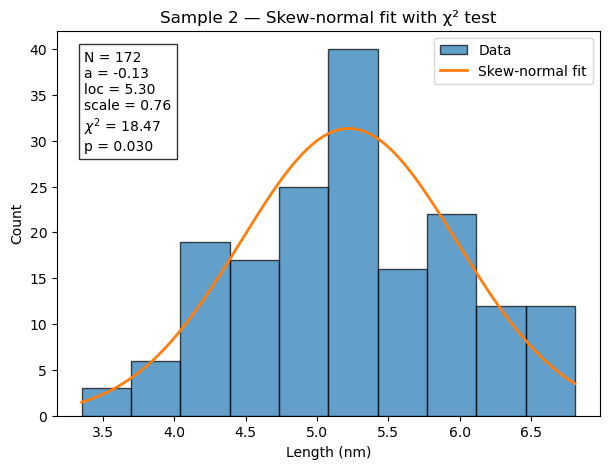

In [115]:
sizes = df["Length"].dropna()
N = len(sizes)

bins = 10
observed, bin_edges = np.histogram(sizes, bins=bins)
bin_width = bin_edges[1] - bin_edges[0]

# Skew-normal fit
a, loc, scale = skewnorm.fit(sizes)

# Expected counts
cdf_values = skewnorm.cdf(bin_edges, a, loc, scale)
expected = N * np.diff(cdf_values)
expected = expected * observed.sum() / expected.sum()

# Chi-square test
chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

# Plot
x = np.linspace(sizes.min(), sizes.max(), 500)
pdf = skewnorm.pdf(x, a, loc, scale)

plt.figure(figsize=(7, 5))
plt.hist(sizes, bins=10, alpha=0.7, edgecolor="black", label="Data")
plt.plot(x, pdf * N * bin_width, linewidth=2, label="Skew-normal fit")

plt.xlabel("Length (nm)")
plt.ylabel("Count")
plt.title("Sample 2 — Skew-normal fit with χ² test")

plt.text(
    0.05, 0.95,
    f"N = {N}\n"
    f"a = {a:.2f}\n"
    f"loc = {loc:.2f}\n"
    f"scale = {scale:.2f}\n"
    f"$\\chi^2$ = {chi2:.2f}\n"
    f"p = {p_value:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid(False)
plt.show()